In [1]:
# WSI-only multiclass pipeline setup
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import mutual_info_score

# Paths and target config
data_path = Path("/app/data/yash-m2m/Data/full_data_table.csv")
wsi_feature_dir = Path("/app/data/yash-m2m/Data/Features/WSI Features")

target_col = "class_labels"
wsi_exam_col = "chosen_exam"
allowed_labels = ["NON_ccA/B", "ccB_only", "ccA_only", "SHARED_ccA/B"]
random_state = 123

## 1) Build WSI-only dataset
Load the clinical table, map each sample to its WSI embedding, and keep only rows with valid embeddings and labels.

In [2]:
df = pd.read_csv(data_path, index_col=0)

required_cols = [target_col, wsi_exam_col]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns in full_data_table.csv: {missing_required}")

unexpected_labels = set(df[target_col].dropna().astype(str).unique()) - set(allowed_labels)
if unexpected_labels:
    raise ValueError(f"Unexpected values in {target_col}: {sorted(unexpected_labels)}")

def load_wsi_embedding(npz_name: str):
    npz_path = wsi_feature_dir / str(npz_name)
    if not npz_path.exists():
        return None
    with np.load(npz_path) as data:
        return np.ravel(data["arr_0"]).astype(float)

wsi_df = df[[target_col, wsi_exam_col]].copy()
wsi_df["wsi_embedding"] = wsi_df[wsi_exam_col].apply(load_wsi_embedding)

n_missing_embeddings = int(wsi_df["wsi_embedding"].isna().sum())
wsi_df = wsi_df.dropna(subset=[target_col, "wsi_embedding"]).copy()

embedding_lengths = wsi_df["wsi_embedding"].apply(len)
if embedding_lengths.nunique() != 1:
    raise ValueError(
        f"WSI embedding lengths are inconsistent: {embedding_lengths.value_counts().to_dict()}"
    )

wsi_feature_df = pd.DataFrame(
    wsi_df["wsi_embedding"].tolist(),
    index=wsi_df.index,
    columns=[f"wsi_{i:04d}" for i in range(int(embedding_lengths.iloc[0]))],
)

X_wsi = wsi_feature_df.apply(pd.to_numeric, errors="coerce")
y_wsi = wsi_df[target_col].astype(str)
class_order = allowed_labels.copy()

print("Loaded rows with valid WSI:", len(X_wsi))
print("Missing WSI embeddings:", n_missing_embeddings)
print("WSI feature dimension:", X_wsi.shape[1])
print("\nClass distribution:")
print(y_wsi.value_counts(dropna=False))

X_wsi.head()

Loaded rows with valid WSI: 323
Missing WSI embeddings: 0
WSI feature dimension: 1024

Class distribution:
class_labels
ccB_only        135
ccA_only        133
SHARED_ccA/B     29
NON_ccA/B        26
Name: count, dtype: int64


,wsi_0000,wsi_0001,wsi_0002,wsi_0003,wsi_0004,wsi_0005,wsi_0006,wsi_0007,wsi_0008,wsi_0009,...,wsi_1014,wsi_1015,wsi_1016,wsi_1017,wsi_1018,wsi_1019,wsi_1020,wsi_1021,wsi_1022,wsi_1023
TCGA-A3-3311,0.094205,0.007828,0.013351,0.020291,0.013857,0.003229,0.072589,0.050152,0.065535,0.016127,...,0.033546,0.010505,0.030839,0.004469,0.000782,0.031042,0.039687,0.005163,0.017557,0.047203
TCGA-A3-3316,0.082407,0.007476,0.011442,0.025793,0.014859,0.002722,0.062528,0.054409,0.056407,0.020648,...,0.023399,0.010450,0.025932,0.007075,0.000864,0.020411,0.042243,0.009459,0.023266,0.065137
TCGA-A3-3317,0.080404,0.016842,0.007083,0.034550,0.014582,0.002194,0.079892,0.059431,0.079821,0.020173,...,0.065695,0.006913,0.020288,0.006504,0.000585,0.028285,0.047470,0.008491,0.017466,0.082171
TCGA-A3-3320,0.091176,0.007396,0.010124,0.033648,0.015745,0.002486,0.093777,0.055947,0.063832,0.014052,...,0.015950,0.013336,0.020499,0.017306,0.001141,0.020963,0.049558,0.006282,0.030056,0.041318
TCGA-A3-3322,0.079067,0.011373,0.006703,0.027626,0.012603,0.001318,0.090948,0.057711,0.060303,0.016628,...,0.057463,0.008065,0.029229,0.005487,0.000812,0.029687,0.039037,0.006389,0.010945,0.051071


## 2) Helper functions
Reusable helpers for multiclass AUC, CV evaluation, and mRMR-MID feature ranking (same strategy as your earlier section).

In [3]:
def multiclass_macro_auc(y_true, y_prob, class_order):
    y_true = pd.Series(y_true).astype(str)
    y_bin = pd.get_dummies(y_true).reindex(columns=class_order, fill_value=0)
    if y_bin.sum(axis=0).min() == 0:
        return float("nan")
    return roc_auc_score(
        y_bin.values,
        y_prob,
        multi_class="ovr",
        average="macro",
    )

def evaluate_models_cv(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    class_order: list,
    random_state: int = 123,
    n_splits: int = 10,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    cv_logit_acc, cv_logit_f1 = [], []
    cv_rf_acc, cv_rf_f1 = [], []
    all_logit_probs, all_logit_obs = [], []
    all_rf_probs, all_rf_obs = [], []

    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        logit = LogisticRegression(
            C=1e10,
            max_iter=3000,
            random_state=random_state,
            solver="lbfgs",
            multi_class="multinomial",
        )
        logit.fit(X_tr, y_tr)
        logit_pred = logit.predict(X_val)
        logit_prob = pd.DataFrame(
            logit.predict_proba(X_val),
            index=X_val.index,
            columns=logit.classes_,
        ).reindex(columns=class_order, fill_value=0.0)

        cv_logit_acc.append(accuracy_score(y_val, logit_pred))
        cv_logit_f1.append(f1_score(y_val, logit_pred, average="macro", zero_division=0))
        all_logit_probs.extend(logit_prob.to_numpy().tolist())
        all_logit_obs.extend(y_val.tolist())

        n_feats = X_tr.shape[1]
        rf = RandomForestClassifier(
            n_estimators=500,
            max_features=max(1, math.floor(math.sqrt(n_feats))),
            random_state=random_state,
        )
        rf.fit(X_tr, y_tr)
        rf_pred = rf.predict(X_val)
        rf_prob = pd.DataFrame(
            rf.predict_proba(X_val),
            index=X_val.index,
            columns=rf.classes_,
        ).reindex(columns=class_order, fill_value=0.0)

        cv_rf_acc.append(accuracy_score(y_val, rf_pred))
        cv_rf_f1.append(f1_score(y_val, rf_pred, average="macro", zero_division=0))
        all_rf_probs.extend(rf_prob.to_numpy().tolist())
        all_rf_obs.extend(y_val.tolist())

    return {
        "cv_logit_acc": float(np.mean(cv_logit_acc)),
        "cv_logit_f1": float(np.mean(cv_logit_f1)),
        "cv_logit_auc": multiclass_macro_auc(all_logit_obs, np.array(all_logit_probs), class_order),
        "cv_rf_acc": float(np.mean(cv_rf_acc)),
        "cv_rf_f1": float(np.mean(cv_rf_f1)),
        "cv_rf_auc": multiclass_macro_auc(all_rf_obs, np.array(all_rf_probs), class_order),
        "all_logit_obs": all_logit_obs,
        "all_logit_probs": np.array(all_logit_probs),
        "all_rf_obs": all_rf_obs,
        "all_rf_probs": np.array(all_rf_probs),
    }

def evaluate_models_test(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    class_order: list,
    random_state: int = 123,
):
    logit = LogisticRegression(
        C=1e10,
        max_iter=3000,
        random_state=random_state,
        solver="lbfgs",
        multi_class="multinomial",
    )
    logit.fit(X_train, y_train)
    logit_pred = logit.predict(X_test)
    logit_prob = pd.DataFrame(
        logit.predict_proba(X_test),
        index=X_test.index,
        columns=logit.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(X_train.shape[1]))),
        random_state=random_state,
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_prob = pd.DataFrame(
        rf.predict_proba(X_test),
        index=X_test.index,
        columns=rf.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    return {
        "test_logit_acc": accuracy_score(y_test, logit_pred),
        "test_logit_f1": f1_score(y_test, logit_pred, average="macro", zero_division=0),
        "test_logit_auc": multiclass_macro_auc(y_test, logit_prob.to_numpy(), class_order),
        "test_rf_acc": accuracy_score(y_test, rf_pred),
        "test_rf_f1": f1_score(y_test, rf_pred, average="macro", zero_division=0),
        "test_rf_auc": multiclass_macro_auc(y_test, rf_prob.to_numpy(), class_order),
        "test_logit_prob": logit_prob,
        "test_rf_prob": rf_prob,
    }

def _discretize_series(s: pd.Series, n_bins: int = 5) -> pd.Series:
    s = s.copy()
    if pd.api.types.is_numeric_dtype(s):
        non_na = s.dropna()
        if non_na.nunique() <= 2:
            return s.fillna(non_na.median() if len(non_na) else 0).astype(float).round().astype(int)
        try:
            binned = pd.qcut(non_na, q=min(n_bins, non_na.nunique()), labels=False, duplicates="drop")
            out = pd.Series(index=s.index, dtype=float)
            out.loc[non_na.index] = binned.astype(float)
            out = out.fillna(out.median() if out.notna().any() else 0)
            return out.astype(int)
        except Exception:
            return pd.factorize(s.fillna("__MISSING__").astype(str))[0]
    return pd.factorize(s.fillna("__MISSING__").astype(str))[0]

def run_python_mrmr_mid_multiclass(
    X_train_df: pd.DataFrame,
    y_train_series: pd.Series,
    n_features: int = 200,
    class_order: list = None,
):
    if class_order is None:
        class_order = sorted(y_train_series.astype(str).unique().tolist())

    y_num = pd.Categorical(y_train_series.astype(str), categories=class_order).codes
    X_disc = pd.DataFrame({c: _discretize_series(X_train_df[c]) for c in X_train_df.columns}, index=X_train_df.index)

    relevance = pd.Series(
        {c: mutual_info_score(X_disc[c].astype(int), y_num.astype(int)) for c in X_disc.columns}
    )

    cols = list(X_disc.columns)
    redundancy = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, ci in enumerate(cols):
        xi = X_disc[ci].astype(int)
        for j in range(i + 1, len(cols)):
            cj = cols[j]
            xj = X_disc[cj].astype(int)
            mi_ij = mutual_info_score(xi, xj)
            redundancy.loc[ci, cj] = mi_ij
            redundancy.loc[cj, ci] = mi_ij

    selected = []
    remaining = cols.copy()

    first = relevance.sort_values(ascending=False).index[0]
    selected.append(first)
    remaining.remove(first)

    while len(selected) < min(n_features, len(cols)) and remaining:
        scores = {}
        for c in remaining:
            red = redundancy.loc[c, selected].mean() if selected else 0.0
            scores[c] = relevance[c] - red

        score_series = pd.Series(scores)
        best_score = score_series.max()
        tied = score_series[score_series == best_score].index.tolist()
        if len(tied) > 1:
            tied = sorted(tied, key=lambda k: (-relevance[k], k))
        best = tied[0]

        selected.append(best)
        remaining.remove(best)

    return selected

In [7]:
# Performance patch: prefilter before mRMR redundancy to avoid full 1024x1024 MI matrix
def run_python_mrmr_mid_multiclass(
    X_train_df: pd.DataFrame,
    y_train_series: pd.Series,
    n_features: int = 120,
    class_order: list = None,
    prefilter_multiplier: int = 2,
):
    if class_order is None:
        class_order = sorted(y_train_series.astype(str).unique().tolist())

    y_num = pd.Categorical(y_train_series.astype(str), categories=class_order).codes
    X_disc_all = pd.DataFrame({c: _discretize_series(X_train_df[c]) for c in X_train_df.columns}, index=X_train_df.index)

    relevance_all = pd.Series(
        {c: mutual_info_score(X_disc_all[c].astype(int), y_num.astype(int)) for c in X_disc_all.columns}
    ).sort_values(ascending=False)

    prefilter_n = min(len(relevance_all), max(n_features * prefilter_multiplier, n_features))
    pre_cols = relevance_all.index[:prefilter_n].tolist()
    X_disc = X_disc_all[pre_cols]
    relevance = relevance_all.loc[pre_cols]

    cols = list(X_disc.columns)
    redundancy = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, ci in enumerate(cols):
        xi = X_disc[ci].astype(int)
        for j in range(i + 1, len(cols)):
            cj = cols[j]
            xj = X_disc[cj].astype(int)
            mi_ij = mutual_info_score(xi, xj)
            redundancy.loc[ci, cj] = mi_ij
            redundancy.loc[cj, ci] = mi_ij

    selected = []
    remaining = cols.copy()

    first = relevance.sort_values(ascending=False).index[0]
    selected.append(first)
    remaining.remove(first)

    while len(selected) < min(n_features, len(cols)) and remaining:
        scores = {}
        for c in remaining:
            red = redundancy.loc[c, selected].mean() if selected else 0.0
            scores[c] = relevance[c] - red

        score_series = pd.Series(scores)
        best_score = score_series.max()
        tied = score_series[score_series == best_score].index.tolist()
        if len(tied) > 1:
            tied = sorted(tied, key=lambda k: (-relevance[k], k))
        best = tied[0]

        selected.append(best)
        remaining.remove(best)

    return selected

## 3) Baseline with all WSI features
Train Logistic and Random Forest on all available WSI dimensions (expected 1024).

In [4]:
X_train_wsi, X_test_wsi, y_train_wsi, y_test_wsi = train_test_split(
    X_wsi,
    y_wsi,
    test_size=0.2,
    stratify=y_wsi,
    random_state=random_state,
 )

all_wsi_cv = evaluate_models_cv(
    X_train=X_train_wsi,
    y_train=y_train_wsi,
    class_order=class_order,
    random_state=random_state,
    n_splits=10,
 )

all_wsi_test = evaluate_models_test(
    X_train=X_train_wsi,
    y_train=y_train_wsi,
    X_test=X_test_wsi,
    y_test=y_test_wsi,
    class_order=class_order,
    random_state=random_state,
 )

all_wsi_summary = pd.Series({
    "n_samples": len(X_wsi),
    "n_features": X_wsi.shape[1],
    "cv_logit_acc": all_wsi_cv["cv_logit_acc"],
    "cv_logit_macro_f1": all_wsi_cv["cv_logit_f1"],
    "cv_logit_macro_auc": all_wsi_cv["cv_logit_auc"],
    "cv_rf_acc": all_wsi_cv["cv_rf_acc"],
    "cv_rf_macro_f1": all_wsi_cv["cv_rf_f1"],
    "cv_rf_macro_auc": all_wsi_cv["cv_rf_auc"],
    "test_logit_acc": all_wsi_test["test_logit_acc"],
    "test_logit_macro_f1": all_wsi_test["test_logit_f1"],
    "test_logit_macro_auc": all_wsi_test["test_logit_auc"],
    "test_rf_acc": all_wsi_test["test_rf_acc"],
    "test_rf_macro_f1": all_wsi_test["test_rf_f1"],
    "test_rf_macro_auc": all_wsi_test["test_rf_auc"],
})

print("All-WSI baseline results:")
all_wsi_summary

All-WSI baseline results:


n_samples                323.000000
n_features              1024.000000
cv_logit_acc               0.399538
cv_logit_macro_f1          0.293514
cv_logit_macro_auc         0.546118
cv_rf_acc                  0.480154
cv_rf_macro_f1             0.261032
cv_rf_macro_auc            0.561244
test_logit_acc             0.476923
test_logit_macro_f1        0.345061
test_logit_macro_auc       0.574471
test_rf_acc                0.569231
test_rf_macro_f1           0.311334
test_rf_macro_auc          0.595946
dtype: float64

## 4) Feature selection on WSI only (mRMR-MID)
Use the same leakage-safe strategy as before: rank features on an outer training split only.

In [8]:
# Outer split for leakage-safe feature selection + holdout evaluation
X_outer_train, X_outer_test, y_outer_train, y_outer_test = train_test_split(
    X_wsi,
    y_wsi,
    test_size=0.2,
    stratify=y_wsi,
    random_state=random_state,
 )

# Practical default for runtime; raise toward 200 if you want a wider search.
max_features_to_rank = min(120, X_outer_train.shape[1])

selected_wsi_features = run_python_mrmr_mid_multiclass(
    X_train_df=X_outer_train,
    y_train_series=y_outer_train,
    n_features=max_features_to_rank,
    class_order=class_order,
)

print(f"Ranked WSI features: {len(selected_wsi_features)}")
print("Top 20 selected features:")
print(selected_wsi_features[:20])

Ranked WSI features: 120
Top 20 selected features:
['wsi_0433', 'wsi_0033', 'wsi_0296', 'wsi_0259', 'wsi_0893', 'wsi_0890', 'wsi_0127', 'wsi_0163', 'wsi_1019', 'wsi_0731', 'wsi_0120', 'wsi_0582', 'wsi_0955', 'wsi_0481', 'wsi_0678', 'wsi_0179', 'wsi_0555', 'wsi_0654', 'wsi_0681', 'wsi_0509']


## 5) Top-k scan over selected WSI features
Evaluate Logistic and RF across increasing k to find the best compact WSI-only model.

In [9]:
results = []

# Dense early grid + coarser tail for speed/stability with high-dimensional WSI
k_grid = list(range(1, min(30, len(selected_wsi_features)) + 1))
k_grid += [k for k in [40, 50, 60, 75, 100, 125, 150, 175, 200] if k <= len(selected_wsi_features)]
k_grid = sorted(set(k_grid))

for k in k_grid:
    features_k = selected_wsi_features[:k]
    X_train_k = X_outer_train[features_k]

    cv_res_k = evaluate_models_cv(
        X_train=X_train_k,
        y_train=y_outer_train,
        class_order=class_order,
        random_state=random_state,
        n_splits=10,
    )

    results.append(
        {
            "k": k,
            "logit_f1": cv_res_k["cv_logit_f1"],
            "logit_auc": cv_res_k["cv_logit_auc"],
            "rf_f1": cv_res_k["cv_rf_f1"],
            "rf_auc": cv_res_k["cv_rf_auc"],
        }
    )

results_df = pd.DataFrame(results).sort_values("k").reset_index(drop=True)

best_logit_f1_idx = results_df["logit_f1"].idxmax()
best_logit_auc_idx = results_df["logit_auc"].idxmax()
best_rf_f1_idx = results_df["rf_f1"].idxmax()
best_rf_auc_idx = results_df["rf_auc"].idxmax()

k_best_logit_f1 = int(results_df.loc[best_logit_f1_idx, "k"])
k_best_logit_auc = int(results_df.loc[best_logit_auc_idx, "k"])
k_best_rf_f1 = int(results_df.loc[best_rf_f1_idx, "k"])
k_best_rf_auc = int(results_df.loc[best_rf_auc_idx, "k"])

best_summary = pd.DataFrame(
    {
        "model": ["Logistic", "Logistic", "RF", "RF"],
        "metric": ["Macro-F1", "Macro-AUC", "Macro-F1", "Macro-AUC"],
        "best_k": [k_best_logit_f1, k_best_logit_auc, k_best_rf_f1, k_best_rf_auc],
        "best_value": [
            results_df.loc[best_logit_f1_idx, "logit_f1"],
            results_df.loc[best_logit_auc_idx, "logit_auc"],
            results_df.loc[best_rf_f1_idx, "rf_f1"],
            results_df.loc[best_rf_auc_idx, "rf_auc"],
        ],
    }
)

print("Best CV values by model/metric:")
display(best_summary)

/root/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/root/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Best CV values by model/metric:


,model,metric,best_k,best_value
0,Logistic,Macro-F1,10,0.343389
1,Logistic,Macro-AUC,9,0.663226
2,RF,Macro-F1,11,0.317642
3,RF,Macro-AUC,21,0.674645


## 6) Evaluate best-k model(s) on holdout test
Use the outer holdout split to report final metrics for k chosen by CV.

In [10]:
def evaluate_on_holdout_multiclass(features):
    X_tr = X_outer_train[features]
    X_te = X_outer_test[features]

    test_res = evaluate_models_test(
        X_train=X_tr,
        y_train=y_outer_train,
        X_test=X_te,
        y_test=y_outer_test,
        class_order=class_order,
        random_state=random_state,
    )
    return test_res

print("Holdout test metrics at best-k values:")
for label, k_val in [
    ("Logistic Macro-F1", k_best_logit_f1),
    ("Logistic Macro-AUC", k_best_logit_auc),
    ("RF Macro-F1", k_best_rf_f1),
    ("RF Macro-AUC", k_best_rf_auc),
]:
    feats = selected_wsi_features[:k_val]
    res = evaluate_on_holdout_multiclass(feats)
    print(
        f"  k={k_val:3d} ({label}): "
        f"Logit ACC={res['test_logit_acc']:.3f} F1={res['test_logit_f1']:.3f} AUC={res['test_logit_auc']:.3f} | "
        f"RF ACC={res['test_rf_acc']:.3f} F1={res['test_rf_f1']:.3f} AUC={res['test_rf_auc']:.3f}"
    )

# Single best-k choice for plotting/comparison (highest CV Macro-F1 across both models)
logit_best_f1 = results_df.loc[best_logit_f1_idx, "logit_f1"]
rf_best_f1 = results_df.loc[best_rf_f1_idx, "rf_f1"]
if logit_best_f1 >= rf_best_f1:
    best_k_final = k_best_logit_f1
    best_k_source = f"Logistic Macro-F1 (k={k_best_logit_f1}, F1={logit_best_f1:.3f})"
else:
    best_k_final = k_best_rf_f1
    best_k_source = f"RF Macro-F1 (k={k_best_rf_f1}, F1={rf_best_f1:.3f})"

print(f"\nChosen best-k for WSI-only final view: k={best_k_final} [{best_k_source}]")

best_k_features = selected_wsi_features[:best_k_final]
best_k_cv = evaluate_models_cv(
    X_train=X_outer_train[best_k_features],
    y_train=y_outer_train,
    class_order=class_order,
    random_state=random_state,
    n_splits=10,
)
best_k_test = evaluate_models_test(
    X_train=X_outer_train[best_k_features],
    y_train=y_outer_train,
    X_test=X_outer_test[best_k_features],
    y_test=y_outer_test,
    class_order=class_order,
    random_state=random_state,
)

best_k_summary = pd.Series({
    "best_k": best_k_final,
    "best_k_source": best_k_source,
    "cv_logit_macro_f1": best_k_cv["cv_logit_f1"],
    "cv_logit_macro_auc": best_k_cv["cv_logit_auc"],
    "cv_rf_macro_f1": best_k_cv["cv_rf_f1"],
    "cv_rf_macro_auc": best_k_cv["cv_rf_auc"],
    "test_logit_macro_f1": best_k_test["test_logit_f1"],
    "test_logit_macro_auc": best_k_test["test_logit_auc"],
    "test_rf_macro_f1": best_k_test["test_rf_f1"],
    "test_rf_macro_auc": best_k_test["test_rf_auc"],
})

print("\nBest-k WSI-only summary:")
best_k_summary

Holdout test metrics at best-k values:
  k= 10 (Logistic Macro-F1): Logit ACC=0.569 F1=0.382 AUC=0.592 | RF ACC=0.462 F1=0.252 AUC=0.536
  k=  9 (Logistic Macro-AUC): Logit ACC=0.508 F1=0.286 AUC=0.590 | RF ACC=0.446 F1=0.244 AUC=0.527
  k= 11 (RF Macro-F1): Logit ACC=0.554 F1=0.373 AUC=0.588 | RF ACC=0.492 F1=0.271 AUC=0.591
  k= 21 (RF Macro-AUC): Logit ACC=0.431 F1=0.244 AUC=0.465 | RF ACC=0.554 F1=0.302 AUC=0.601

Chosen best-k for WSI-only final view: k=10 [Logistic Macro-F1 (k=10, F1=0.343)]

Best-k WSI-only summary:


best_k                                                  10
best_k_source           Logistic Macro-F1 (k=10, F1=0.343)
cv_logit_macro_f1                                 0.343389
cv_logit_macro_auc                                0.661745
cv_rf_macro_f1                                    0.305952
cv_rf_macro_auc                                   0.663283
test_logit_macro_f1                               0.381712
test_logit_macro_auc                              0.591577
test_rf_macro_f1                                  0.251837
test_rf_macro_auc                                 0.535514
dtype: object

## 7) Visualize top-k trend and ROC
Plot CV performance vs. k and one-vs-rest ROC curves for the chosen best-k models.

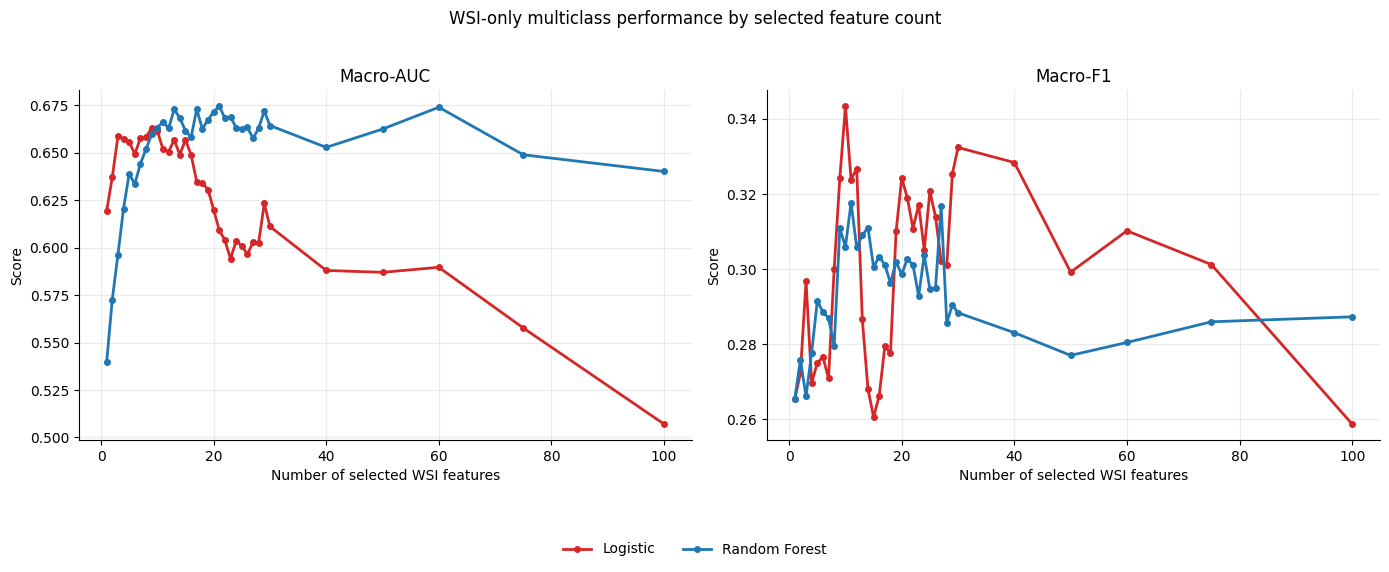

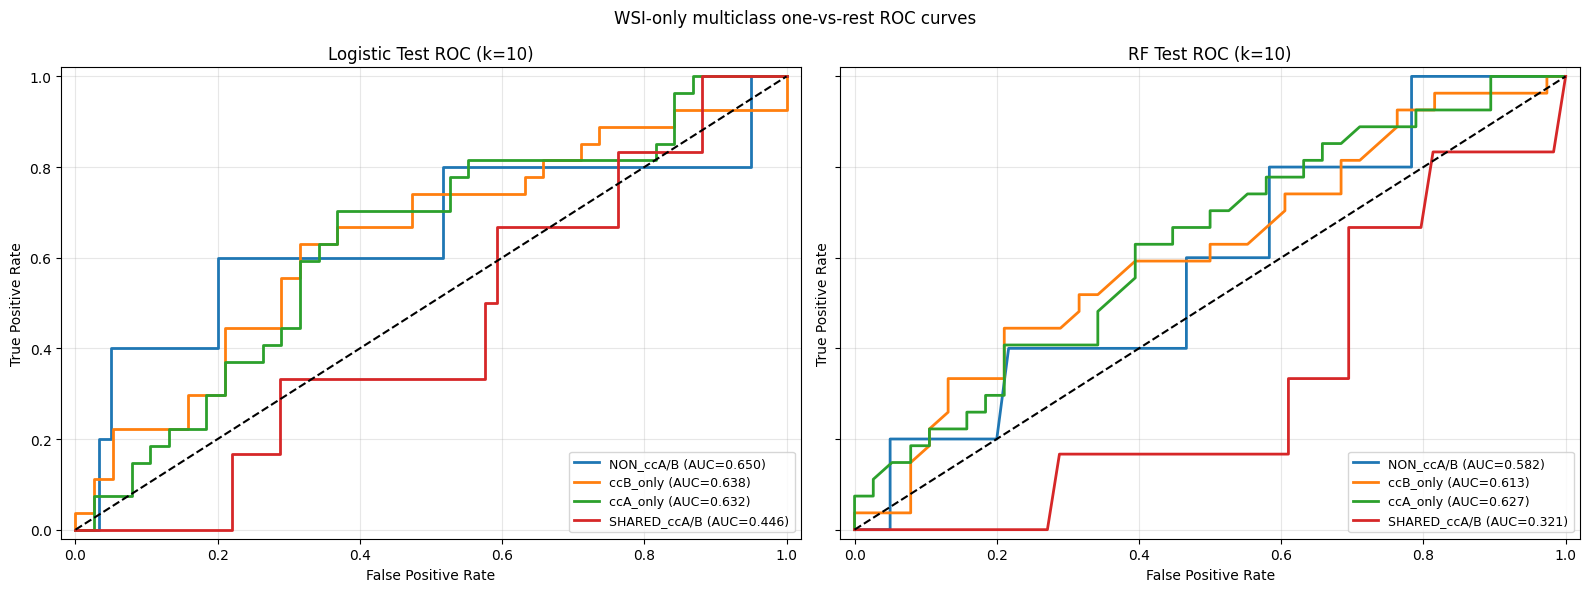

In [11]:
# Performance curves across k
results_long = results_df.melt(
    id_vars=["k"],
    value_vars=["logit_f1", "logit_auc", "rf_f1", "rf_auc"],
    var_name="metric_model",
    value_name="score",
)
results_long[["model", "metric"]] = results_long["metric_model"].str.split("_", expand=True)
results_long["model"] = results_long["model"].map({"logit": "Logistic", "rf": "Random Forest"})
results_long["metric"] = results_long["metric"].map({"f1": "Macro-F1", "auc": "Macro-AUC"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Logistic": "#d62728", "Random Forest": "#1f77b4"}

for ax, metric in zip(axes, ["Macro-AUC", "Macro-F1"]):
    subset = results_long[results_long["metric"] == metric]
    for model in ["Logistic", "Random Forest"]:
        m = subset[subset["model"] == model]
        ax.plot(
            m["k"],
            m["score"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=model,
            color=colors[model],
        )
    ax.set_xlabel("Number of selected WSI features")
    ax.set_ylabel("Score")
    ax.set_title(metric)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25)

fig.legend(["Logistic", "Random Forest"], loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
fig.suptitle("WSI-only multiclass performance by selected feature count", y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.show()

# ROC curves on outer holdout using best-k
best_feats = selected_wsi_features[:best_k_final]
X_train_best = X_outer_train[best_feats]
X_test_best = X_outer_test[best_feats]

logit_best = LogisticRegression(
    C=1e10,
    max_iter=3000,
    random_state=random_state,
    solver="lbfgs",
    multi_class="multinomial",
)
logit_best.fit(X_train_best, y_outer_train)
logit_test_prob = pd.DataFrame(
    logit_best.predict_proba(X_test_best),
    index=X_test_best.index,
    columns=logit_best.classes_,
).reindex(columns=class_order, fill_value=0.0)

rf_best = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(best_feats)))),
    random_state=random_state,
)
rf_best.fit(X_train_best, y_outer_train)
rf_test_prob = pd.DataFrame(
    rf_best.predict_proba(X_test_best),
    index=X_test_best.index,
    columns=rf_best.classes_,
).reindex(columns=class_order, fill_value=0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
y_bin_test = pd.get_dummies(pd.Series(y_outer_test)).reindex(columns=class_order, fill_value=0).values

for i, cls in enumerate(class_order):
    fpr_l, tpr_l, _ = roc_curve(y_bin_test[:, i], logit_test_prob.to_numpy()[:, i])
    auc_l = roc_auc_score(y_bin_test[:, i], logit_test_prob.to_numpy()[:, i])
    axes[0].plot(fpr_l, tpr_l, lw=2, label=f"{cls} (AUC={auc_l:.3f})")

    fpr_r, tpr_r, _ = roc_curve(y_bin_test[:, i], rf_test_prob.to_numpy()[:, i])
    auc_r = roc_auc_score(y_bin_test[:, i], rf_test_prob.to_numpy()[:, i])
    axes[1].plot(fpr_r, tpr_r, lw=2, label=f"{cls} (AUC={auc_r:.3f})")

for ax, title in zip(axes, [f"Logistic Test ROC (k={best_k_final})", f"RF Test ROC (k={best_k_final})"]):
    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.suptitle("WSI-only multiclass one-vs-rest ROC curves")
plt.tight_layout()
plt.show()

# Neural Network model

## 8) Neural network model on WSI features
With 323 samples and 1024 WSI features, deep models are high-risk for overfitting. We will use a small regularized MLP (shallow NN) with scaling + early stopping, then repeat with selected WSI features.

In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def approx_mlp_param_count(n_input: int, n_classes: int, hidden_layers=(64, 32)) -> int:
    dims = [n_input] + list(hidden_layers) + [n_classes]
    params = 0
    for d_in, d_out in zip(dims[:-1], dims[1:]):
        params += d_in * d_out + d_out  # weights + biases
    return params

n_samples = len(X_wsi)
n_features_all = X_wsi.shape[1]
n_classes = len(class_order)
approx_params_all = approx_mlp_param_count(n_features_all, n_classes, hidden_layers=(64, 32))

print("Neural-network feasibility check")
print(f"Samples: {n_samples}")
print(f"Input features (all WSI): {n_features_all}")
print(f"Classes: {n_classes}")
print(f"Approx MLP params (64,32): {approx_params_all:,}")
print(f"Samples per parameter: {n_samples / approx_params_all:.6f}")

if n_samples / approx_params_all < 0.01:
    print("\nInterpretation: very low sample-to-parameter ratio; strong overfitting risk.")
    print("Recommendation: keep network small + regularized and prefer feature selection before NN.")

Neural-network feasibility check
Samples: 323
Input features (all WSI): 1024
Classes: 4
Approx MLP params (64,32): 67,812
Samples per parameter: 0.004763

Interpretation: very low sample-to-parameter ratio; strong overfitting risk.
Recommendation: keep network small + regularized and prefer feature selection before NN.


### 8.1) MLP baseline on all 1024 WSI features
This is a shallow neural net baseline (scaler + MLP) evaluated with CV and held-out test, analogous to previous models.

In [13]:
def evaluate_mlp_cv_test(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    class_order: list,
    random_state: int = 123,
    n_splits: int = 10,
    hidden_layers=(64, 32),
    alpha: float = 1e-3,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_acc, cv_f1 = [], []
    all_probs, all_obs = [], []

    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        mlp_pipe = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "mlp",
                    MLPClassifier(
                        hidden_layer_sizes=hidden_layers,
                        activation="relu",
                        solver="adam",
                        alpha=alpha,
                        learning_rate_init=1e-3,
                        max_iter=600,
                        early_stopping=True,
                        validation_fraction=0.15,
                        n_iter_no_change=25,
                        random_state=random_state,
                    ),
                ),
            ]
        )

        mlp_pipe.fit(X_tr, y_tr)
        y_pred = mlp_pipe.predict(X_val)
        y_prob = pd.DataFrame(
            mlp_pipe.predict_proba(X_val),
            index=X_val.index,
            columns=mlp_pipe.named_steps["mlp"].classes_,
        ).reindex(columns=class_order, fill_value=0.0)

        cv_acc.append(accuracy_score(y_val, y_pred))
        cv_f1.append(f1_score(y_val, y_pred, average="macro", zero_division=0))
        all_probs.extend(y_prob.to_numpy().tolist())
        all_obs.extend(y_val.tolist())

    cv_auc = multiclass_macro_auc(all_obs, np.array(all_probs), class_order)

    final_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPClassifier(
                    hidden_layer_sizes=hidden_layers,
                    activation="relu",
                    solver="adam",
                    alpha=alpha,
                    learning_rate_init=1e-3,
                    max_iter=600,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=25,
                    random_state=random_state,
                ),
            ),
        ]
    )
    final_pipe.fit(X_train, y_train)
    y_test_pred = final_pipe.predict(X_test)
    y_test_prob = pd.DataFrame(
        final_pipe.predict_proba(X_test),
        index=X_test.index,
        columns=final_pipe.named_steps["mlp"].classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    out = {
        "cv_acc": float(np.mean(cv_acc)),
        "cv_macro_f1": float(np.mean(cv_f1)),
        "cv_macro_auc": cv_auc,
        "test_acc": accuracy_score(y_test, y_test_pred),
        "test_macro_f1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_macro_auc": multiclass_macro_auc(y_test, y_test_prob.to_numpy(), class_order),
        "all_cv_obs": all_obs,
        "all_cv_probs": np.array(all_probs),
        "test_prob_df": y_test_prob,
    }
    return out

mlp_all_res = evaluate_mlp_cv_test(
    X_train=X_train_wsi,
    y_train=y_train_wsi,
    X_test=X_test_wsi,
    y_test=y_test_wsi,
    class_order=class_order,
    random_state=random_state,
    n_splits=10,
    hidden_layers=(64, 32),
    alpha=1e-3,
)

mlp_all_summary = pd.Series({
    "model": "MLP (64,32)",
    "input": "All WSI features",
    "n_features": X_train_wsi.shape[1],
    "cv_acc": mlp_all_res["cv_acc"],
    "cv_macro_f1": mlp_all_res["cv_macro_f1"],
    "cv_macro_auc": mlp_all_res["cv_macro_auc"],
    "test_acc": mlp_all_res["test_acc"],
    "test_macro_f1": mlp_all_res["test_macro_f1"],
    "test_macro_auc": mlp_all_res["test_macro_auc"],
})

mlp_all_summary

model                  MLP (64,32)
input             All WSI features
n_features                    1024
cv_acc                    0.441385
cv_macro_f1               0.260488
cv_macro_auc              0.522274
test_acc                  0.523077
test_macro_f1             0.365809
test_macro_auc            0.603008
dtype: object

### 8.2) MLP with selected WSI features (top-k scan)
Reuse the mRMR-ranked WSI features and scan k to find a compact neural-network input size.

In [17]:
mlp_k_results = []

# Keep k values that already worked well in prior models
k_grid_mlp = sorted(set([k for k in k_grid if k <= len(selected_wsi_features)]))

for k in k_grid_mlp:
    feats_k = selected_wsi_features[:k]
    X_tr_k = X_outer_train[feats_k]
    X_te_k = X_outer_test[feats_k]

    # Smaller network for smaller k helps regularization stability.
    if k <= 30:
        hidden = (32,)
    elif k <= 80:
        hidden = (64, 16)
    else:
        hidden = (64, 32)

    res_k = evaluate_mlp_cv_test(
        X_train=X_tr_k,
        y_train=y_outer_train,
        X_test=X_te_k,
        y_test=y_outer_test,
        class_order=class_order,
        random_state=random_state,
        n_splits=10,
        hidden_layers=hidden,
        alpha=3e-3,
    )

    mlp_k_results.append(
        {
            "k": k,
            "hidden_layers": str(hidden),
            "cv_f1": res_k["cv_macro_f1"],
            "cv_auc": res_k["cv_macro_auc"],
            "test_f1": res_k["test_macro_f1"],
            "test_auc": res_k["test_macro_auc"],
        }
    )

mlp_k_df = pd.DataFrame(mlp_k_results).sort_values("k").reset_index(drop=True)

best_mlp_f1_idx = mlp_k_df["cv_f1"].idxmax()
best_mlp_auc_idx = mlp_k_df["cv_auc"].idxmax()
k_best_mlp_f1 = int(mlp_k_df.loc[best_mlp_f1_idx, "k"])
k_best_mlp_auc = int(mlp_k_df.loc[best_mlp_auc_idx, "k"])

print("Best MLP k by CV Macro-F1:", k_best_mlp_f1, "value=", round(float(mlp_k_df.loc[best_mlp_f1_idx, "cv_f1"]), 4))
print("Best MLP k by CV Macro-AUC:", k_best_mlp_auc, "value=", round(float(mlp_k_df.loc[best_mlp_auc_idx, "cv_auc"]), 4))
mlp_k_df.head(10)

Best MLP k by CV Macro-F1: 4 value= 0.308
Best MLP k by CV Macro-AUC: 4 value= 0.6319


,k,hidden_layers,cv_f1,cv_auc,test_f1,test_auc
0,1,"(32,)",0.256784,0.540462,0.184489,0.551572
1,2,"(32,)",0.256735,0.543390,0.264723,0.546315
2,3,"(32,)",0.280140,0.611861,0.268439,0.505142
3,4,"(32,)",0.307990,0.631894,0.312417,0.604250
4,5,"(32,)",0.224958,0.492511,0.275783,0.530319
5,6,"(32,)",0.276184,0.575599,0.277401,0.533345
6,7,"(32,)",0.253970,0.570017,0.215552,0.495982
7,8,"(32,)",0.217634,0.556870,0.234812,0.585736
8,9,"(32,)",0.275391,0.614303,0.242647,0.594827
9,10,"(32,)",0.208255,0.521943,0.230357,0.454018


### 8.3) Final MLP at best k + comparison with previous models

In [18]:
import ast

best_mlp_hidden = ast.literal_eval(mlp_k_df.loc[best_mlp_f1_idx, "hidden_layers"])
best_mlp_features = selected_wsi_features[:k_best_mlp_f1]

mlp_best_res = evaluate_mlp_cv_test(
    X_train=X_outer_train[best_mlp_features],
    y_train=y_outer_train,
    X_test=X_outer_test[best_mlp_features],
    y_test=y_outer_test,
    class_order=class_order,
    random_state=random_state,
    n_splits=10,
    hidden_layers=best_mlp_hidden,
    alpha=3e-3,
)

comparison_rows = [
    {
        "model": "Logistic (best-k previous)",
        "k": best_k_final,
        "cv_macro_f1": best_k_cv["cv_logit_f1"],
        "cv_macro_auc": best_k_cv["cv_logit_auc"],
        "test_macro_f1": best_k_test["test_logit_f1"],
        "test_macro_auc": best_k_test["test_logit_auc"],
    },
    {
        "model": "Random Forest (best-k previous)",
        "k": best_k_final,
        "cv_macro_f1": best_k_cv["cv_rf_f1"],
        "cv_macro_auc": best_k_cv["cv_rf_auc"],
        "test_macro_f1": best_k_test["test_rf_f1"],
        "test_macro_auc": best_k_test["test_rf_auc"],
    },
    {
        "model": f"MLP {best_mlp_hidden}",
        "k": k_best_mlp_f1,
        "cv_macro_f1": mlp_best_res["cv_macro_f1"],
        "cv_macro_auc": mlp_best_res["cv_macro_auc"],
        "test_macro_f1": mlp_best_res["test_macro_f1"],
        "test_macro_auc": mlp_best_res["test_macro_auc"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,model,k,cv_macro_f1,cv_macro_auc,test_macro_f1,test_macro_auc
0,Logistic (best-k previous),10,0.343389,0.661745,0.381712,0.591577
1,Random Forest (best-k previous),10,0.305952,0.663283,0.251837,0.535514
2,"MLP (32,)",4,0.307990,0.631894,0.312417,0.604250


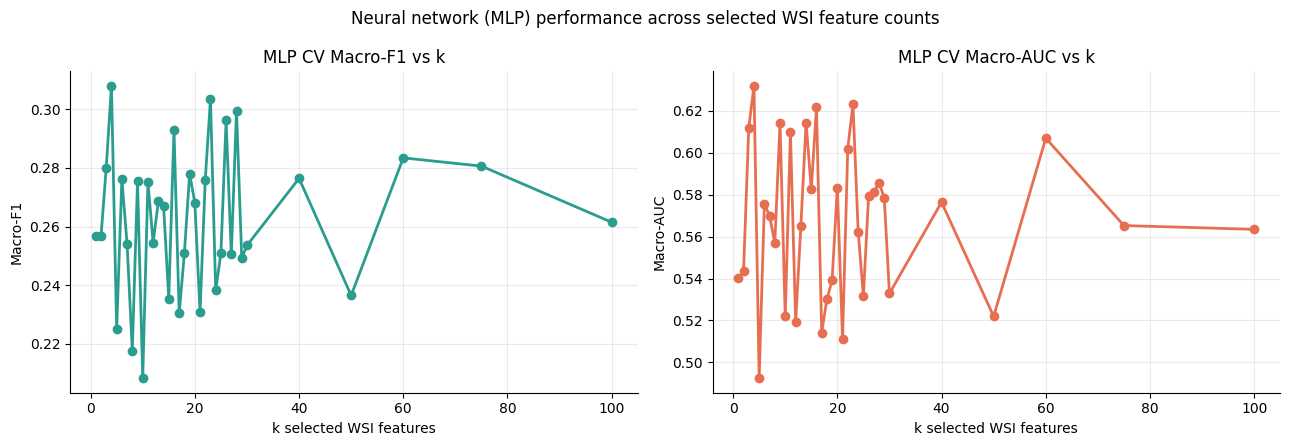

In [19]:
# Plot CV trend for MLP top-k scan
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(mlp_k_df["k"], mlp_k_df["cv_f1"], marker="o", color="#2a9d8f", linewidth=2)
axes[0].set_title("MLP CV Macro-F1 vs k")
axes[0].set_xlabel("k selected WSI features")
axes[0].set_ylabel("Macro-F1")
axes[0].grid(alpha=0.25)

axes[1].plot(mlp_k_df["k"], mlp_k_df["cv_auc"], marker="o", color="#e76f51", linewidth=2)
axes[1].set_title("MLP CV Macro-AUC vs k")
axes[1].set_xlabel("k selected WSI features")
axes[1].set_ylabel("Macro-AUC")
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Neural network (MLP) performance across selected WSI feature counts")
plt.tight_layout()
plt.show()